# Lab: XAI and Uncertainty for Time-Series Forecasting (Panama Load)

You are data scientists at a grid operator in Panama. Your task is short-term load forecasting, interpreting model behaviour (XAI), and estimating predictive uncertainty so operators can make safer operational decisions. This notebook walks you through EDA, feature engineering, training a model, SHAP explanations, temporal attribution with occlusion, bootstrap-based variability, and conformal prediction intervals.

Follow the TODO markers in code cells. The dataset is expected at `data/panama_load.csv` and should contain at least a timestamp column and a load column. Optional covariates (temperature, humidity, etc.) are welcome.

In [1]:
# Section 0 - Setup
# Imports, plotting style, and random seed
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf
import shap
import warnings
warnings.filterwarnings('ignore')

# Plot style and seed
sns.set_style('whitegrid')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

c:\Users\anton\OneDrive\Escritorio\MASTER\Etica_IA\Explicabilidad\p3-timeseries-AntonioLDM17\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Section 1 — Load data and basic EDA

Goal: understand the time series, inspect seasonality, and spot anomalies. Follow instructions and fill TODOs.

You can learn more about the dataset at: https://www.kaggle.com/datasets/saurabhshahane/electricity-load-forecasting

In [3]:
# 1) Load data into a DataFrame
path = './data/panama_load.csv'
if not os.path.exists(path):
    print(f'WARNING: {path} not found. Please place the dataset at this path.')
df = pd.read_csv(path)
print(f'Data loaded with shape: {df.shape}')

Data loaded with shape: (48048, 17)


In [4]:
datetime_col = 'datetime' 
load_col = 'nat_demand'  
# Attempt to parse a datetime column robustly
if datetime_col not in df.columns:
    # try to guess a datetime-like column
    for c in df.columns:
        if 'date' in c.lower() or 'time' in c.lower():
            datetime_col = c
            break
print('Using datetime column:', datetime_col)
# Parse datetimes
try:
    df[datetime_col] = pd.to_datetime(df[datetime_col])
except Exception as e:
    print('Error parsing datetimes:', e)
# Set index and sort
df = df.set_index(datetime_col).sort_index()

print('Using load column:', load_col)
# Keep a clean dataframe with at least datetime index and load
data = df[[load_col]].copy()
data.columns = ['load']
data = data.sort_index()
data.head()

Using datetime column: datetime
Using load column: nat_demand


,load
datetime,
2015-01-03 01:00:00,970.3450
2015-01-03 02:00:00,912.1755
2015-01-03 03:00:00,900.2688
2015-01-03 04:00:00,889.9538
2015-01-03 05:00:00,893.6865


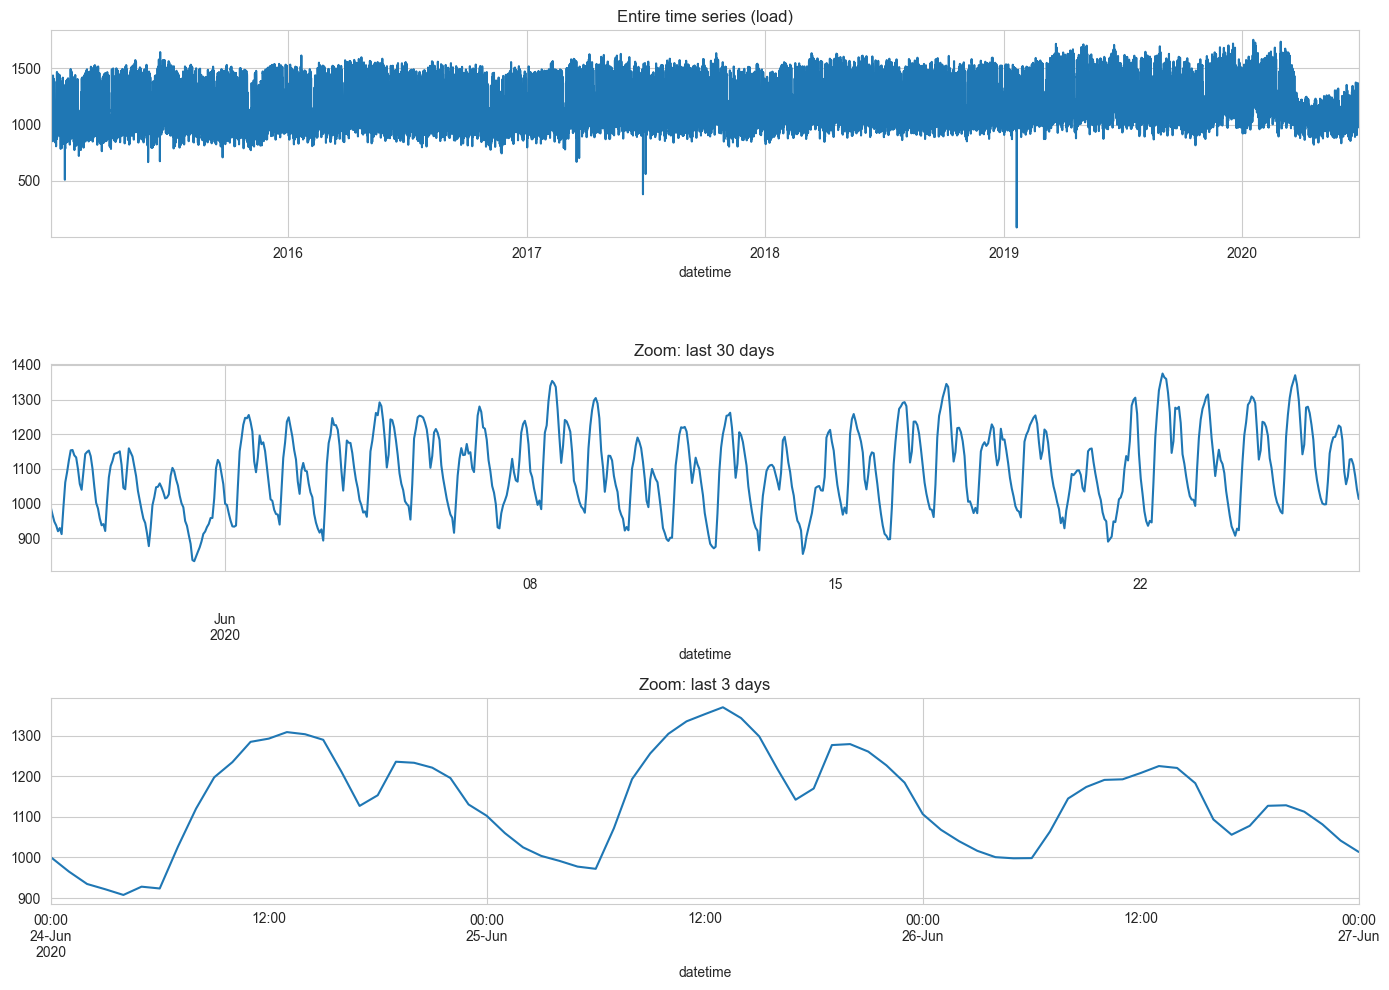

In [5]:
# 2) Basic plots: entire series, one month, a couple of days
fig, ax = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
# Entire series
data['load'].plot(ax=ax[0], title='Entire time series (load)')
# Zoom into one month (choose the last available month)
last = data.index.max()
month_start = (last - pd.Timedelta(days=30)).ceil('D')
data.loc[month_start:last, 'load'].plot(ax=ax[1], title='Zoom: last 30 days')
# Zoom into a couple of days
days_start = (last - pd.Timedelta(days=3)).ceil('D')
data.loc[days_start:last, 'load'].plot(ax=ax[2], title='Zoom: last 3 days')
plt.tight_layout()
plt.show()

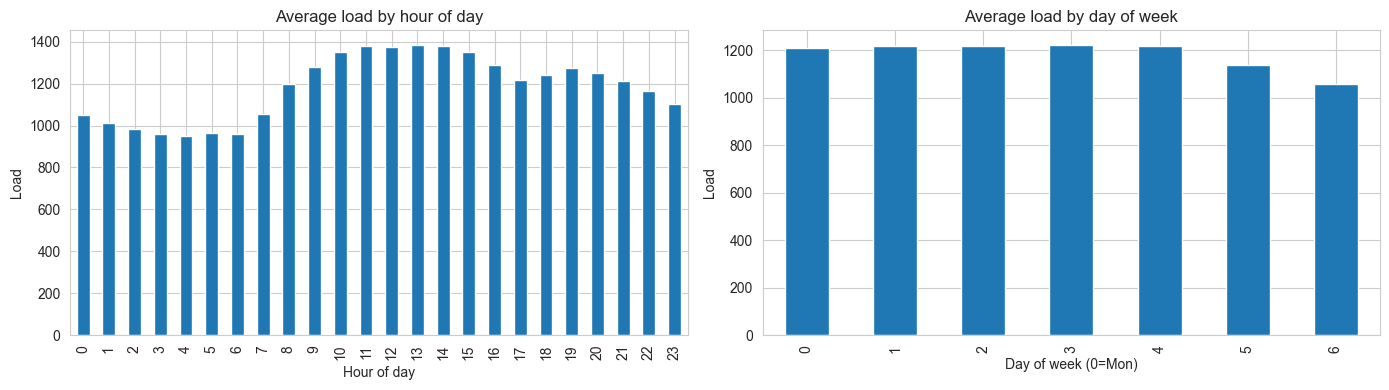

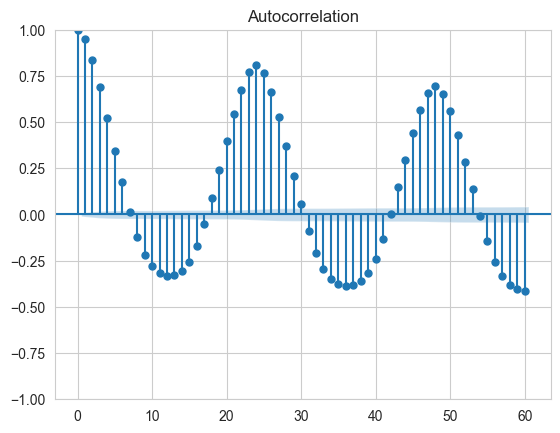

In [6]:
# 3) Average load by hour-of-day and day-of-week
df_feats = data.copy()
df_feats['hour'] = df_feats.index.hour
df_feats['dow'] = df_feats.index.dayofweek
hourly = df_feats.groupby('hour')['load'].mean()
dow = df_feats.groupby('dow')['load'].mean()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
hourly.plot(kind='bar', ax=ax1, title='Average load by hour of day')
ax1.set_xlabel('Hour of day')
ax1.set_ylabel('Load')
dow.plot(kind='bar', ax=ax2, title='Average load by day of week')
ax2.set_xlabel('Day of week (0=Mon)')
ax2.set_ylabel('Load')
plt.tight_layout()
plot_acf(data['load'].dropna(), lags=60)
plt.show()


- TODO: Inspect the previous plots and comment on the patterns you can distinguish

>>>
>
>From the full time-series plot, we can see a generally **stable long-term behaviour** with a clear **repeating pattern** and some occasional **sharp drops** that likely correspond to grid incidents or missing/erroneous measurements. The overall load level fluctuates within a fairly consistent range over the years.
>
>In the **last 30 days**, a very strong **daily seasonality** becomes apparent: each day shows a similar rise-and-fall structure, with low demand during the night and much higher demand during daytime hours.
>
>Zooming further into the **last 3 days**, the typical daily load curve is even clearer. The load stays low during the early morning hours, increases sharply after sunrise, peaks around **midday / early afternoon**, and gradually decreases again later in the day, although remaining relatively elevated in the evening.
>
>The **average load by hour of day** confirms this pattern: minimum demand occurs between roughly 3–6 AM, followed by a steep morning ramp-up, a peak around 11 AM–2 PM, and a moderate decline into the evening.
>
>The **day-of-week averages** reveal a clear **weekly seasonality**: Monday to Friday exhibit higher and fairly similar load levels, while Saturday shows a moderate drop and Sunday displays significantly lower demand — consistent with reduced economic and industrial activity during weekends.
>
>Finally, the **autocorrelation function (ACF)** shows very strong autocorrelation at short lags and distinct positive peaks at multiples of 24 (24, 48, 72…), indicating a robust **24-hour periodicity**. The oscillating positive/negative pattern also suggests a well-defined daily cycle and some weekly structure.
>
>**In summary:** the series exhibits strong **daily and weekly seasonality**, stable overall trends, and a few isolated anomalous points.



## Section 2 — Turn time series into supervised learning data

We convert the time series into a tabular supervised problem: predict 1-step-ahead load from lag features, rolling statistics and calendar features.
Fill TODOs in the helper function below.

In [7]:
def make_supervised(df, target_col='load', horizon=1, lags=None):
    """Create supervised features for a 1-step-ahead forecast."""
    if lags is None:
        lags = [1, 24, 48, 168]  # t-1, t-24 (daily), t-48, t-168 (weekly)
    X = pd.DataFrame(index=df.index)
    # Lag features
    for lag in lags:
        X[f'lag_{lag}'] = df[target_col].shift(lag)
    # Rolling features: 24-hour and 7-day rolling mean/std
    X['rmean_24'] = df[target_col].rolling(window=24, min_periods=1).mean().shift(1)
    X['rstd_24'] = df[target_col].rolling(window=24, min_periods=1).std().shift(1)
    X['rmean_168'] = df[target_col].rolling(window=168, min_periods=1).mean().shift(1)
    # Calendar features
    X['hour'] = df.index.hour
    X['dow'] = df.index.dayofweek
    X['is_weekend'] = (X['dow'] >= 5).astype(int)
    X['month'] = df.index.month
    # Target (1-step ahead by default)
    y = df[target_col].shift(-horizon)
    # Align and drop NaNs caused by shifts
    X = X.loc[~y.isna()]
    y = y.loc[X.index]
    return X, y
# Build supervised data
X, y = make_supervised(data, target_col='load', horizon=1)
print('X shape:', X.shape, 'y shape:', y.shape)
# show a few rows
X.head()

X shape: (48047, 11) y shape: (48047,)


,lag_1,lag_24,lag_48,lag_168,rmean_24,rstd_24,rmean_168,hour,dow,is_weekend,month
datetime,,,,,,,,,,,
2015-01-03 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,5,1,1
2015-01-03 02:00:00,970.3450,NaN,NaN,NaN,970.345000,NaN,970.345000,2,5,1,1
2015-01-03 03:00:00,912.1755,NaN,NaN,NaN,941.260250,41.132048,941.260250,3,5,1,1
2015-01-03 04:00:00,900.2688,NaN,NaN,NaN,927.596433,37.496964,927.596433,4,5,1,1
2015-01-03 05:00:00,889.9538,NaN,NaN,NaN,918.185775,35.938700,918.185775,5,5,1,1


## Section 3 — Time-based train / calibration / test split

Random splits leak future information in time series. We'll split chronologically: TRAIN (first 60%), CALIBRATION (next 20%), TEST (last 20%). The calibration set will be used for conformal prediction intervals.


In [9]:
# Chronological split
n = len(X)
i_train = int(n * 0.6)
i_cal = int(n * 0.8)
X_train = X.iloc[:i_train]
y_train = y.iloc[:i_train]
X_cal = X.iloc[i_train:i_cal]
y_cal = y.iloc[i_train:i_cal]
X_test = X.iloc[i_cal:]
y_test = y.iloc[i_cal:]
print('TRAIN range:', X_train.index.min(), 'to', X_train.index.max(), 'size', len(X_train))
print('CAL range:', X_cal.index.min(), 'to', X_cal.index.max(), 'size', len(X_cal))
print('TEST range:', X_test.index.min(), 'to', X_test.index.max(), 'size', len(X_test))

TRAIN range: 2015-01-03 01:00:00 to 2018-04-18 04:00:00 size 28828
CAL range: 2018-04-18 05:00:00 to 2019-05-23 13:00:00 size 9609
TEST range: 2019-05-23 14:00:00 to 2020-06-26 23:00:00 size 9610


## Section 4 — Baseline model and ML model

We compare a naive baseline (previous value) to a trained tree-based regressor. Evaluate using MAE and RMSE.


Naive baseline MAE: 78.688, RMSE: 100.701
RandomForest MAE: 35.885, RMSE: 54.490


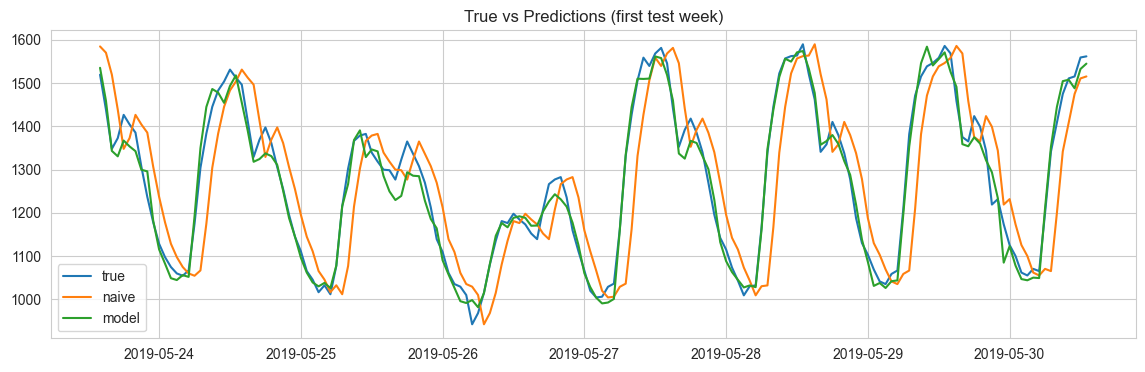

In [10]:
# Naive baseline: predict using lag_1 (t-1). Align carefully.
y_test_index = y_test.index
# Baseline predictions: because target is t, naive is previous observed load at t-1 which is lag_1 feature
yhat_naive = X_test['lag_1']
# Fit a RandomForest as example ML model (students can replace with XGBoost/LGBM)
model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
# TODO: fit the model on (X_train, y_train)
model.fit(X_train, y_train)
# Predict on test
yhat = pd.Series(model.predict(X_test), index=X_test.index)
# Evaluation
def evaluate(y_true, y_pred, label='model'):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)**0.5
    print(f'{label} MAE: {mae:.3f}, RMSE: {rmse:.3f}')

evaluate(y_test, yhat_naive, label='Naive baseline')
evaluate(y_test, yhat, label='RandomForest')
# Plot a selected TEST week: choose first week of test set
try:
    plot_start = X_test.index[0]
    plot_end = plot_start + pd.Timedelta(days=7)
    idx = (y_test.index >= plot_start) & (y_test.index < plot_end)
    plt.figure(figsize=(14, 4))
    plt.plot(y_test.loc[idx].index, y_test.loc[idx].values, label='true')
    plt.plot(yhat_naive.loc[idx].index, yhat_naive.loc[idx].values, label='naive')
    plt.plot(yhat.loc[idx].index, yhat.loc[idx].values, label='model')
    plt.legend()
    plt.title('True vs Predictions (first test week)')
    plt.show()
except Exception as e:
    print('Could not plot test week:', e)

## Section 5 — Global and local XAI with SHAP

We use SHAP to explain feature importance globally and locally. For tree models, TreeExplainer is efficient. For other models, KernelExplainer may be used but is slower.


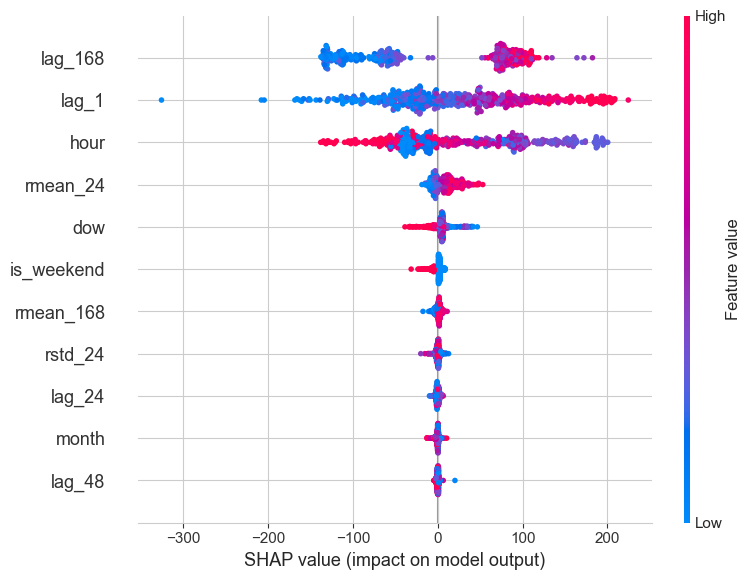

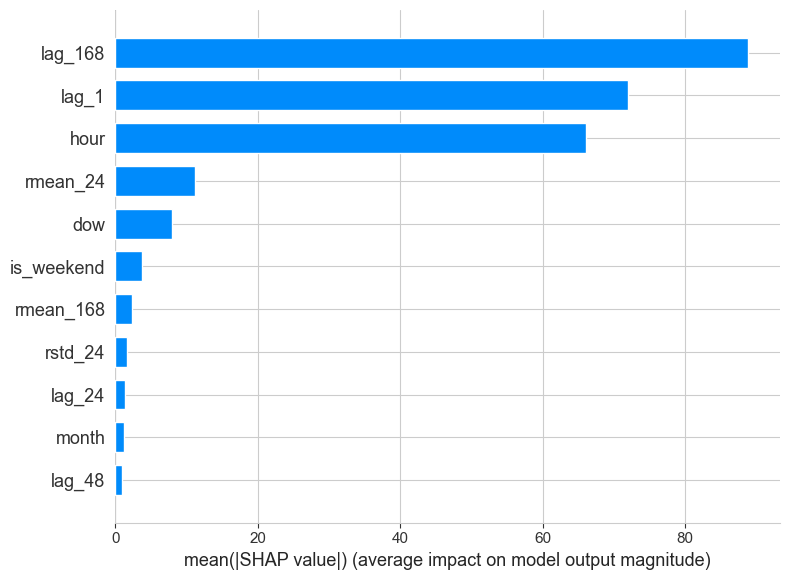

Index with highest load in test: 2020-01-17 13:00:00
Could not produce local SHAP waterfall: The waterfall plot requires an `Explanation` object as the `shap_values` argument.


In [11]:
# Select a subset of X_test for SHAP analysis (to keep compute small)
X_shap = X_test.sample(n=min(500, len(X_test)), random_state=RANDOM_SEED)
# Use TreeExplainer for tree-based models
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)
# Summary plot (beeswarm)
shap.summary_plot(shap_values, X_shap, show=True)
# Bar plot of mean absolute SHAP values
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=True)
# Local explanation for a single interesting point (e.g., highest true load in test)
idx_max = y_test.idxmax()
print('Index with highest load in test:', idx_max)
x_local = X_test.loc[[idx_max]]
try:
    sv_local = explainer.shap_values(x_local)
    shap.plots.waterfall(sv_local[0] if isinstance(sv_local, list) else sv_local, max_display=12)
except Exception as e:
    print('Could not produce local SHAP waterfall:', e)

In [13]:
# --- Simplified Feature Set Based on SHAP ---
important_features = [
    'lag_168', 'lag_1', 'hour', 'rmean_24', 'dow', 'is_weekend'
]

X_train_s = X_train[important_features]
X_cal_s   = X_cal[important_features]
X_test_s  = X_test[important_features]

# Train a simpler Random Forest
model_simplified = RandomForestRegressor(
    n_estimators=100, 
    random_state=RANDOM_SEED,
    n_jobs=-1
)

model_simplified.fit(X_train_s, y_train)

# Predictions
yhat_s = pd.Series(model_simplified.predict(X_test_s), index=X_test_s.index)

# Evaluation
print("=== Performance: Full Model vs Simplified Model ===")
evaluate(y_test, yhat, label="Full model")
evaluate(y_test, yhat_s, label="Simplified model")


=== Performance: Full Model vs Simplified Model ===
Full model MAE: 35.885, RMSE: 54.490
Simplified model MAE: 35.652, RMSE: 53.674


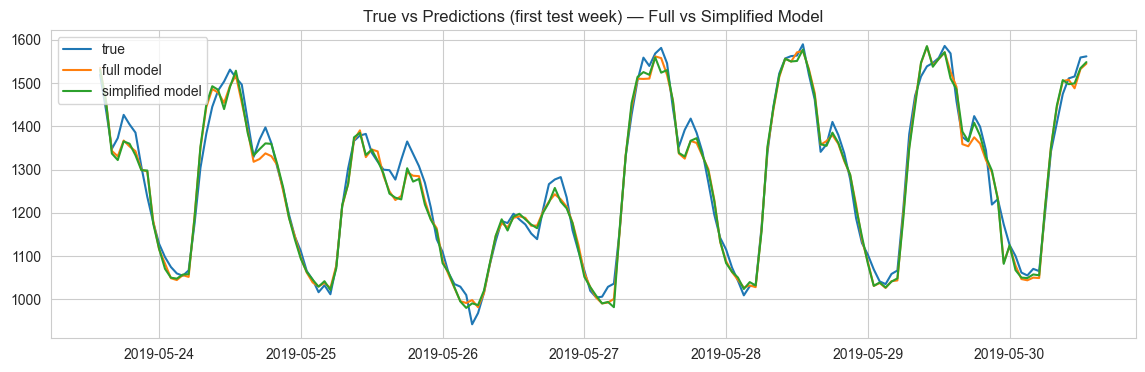

In [14]:
# Plot simplified predictions
plot_start = X_test.index[0]
plot_end = plot_start + pd.Timedelta(days=7)
idx = (y_test.index >= plot_start) & (y_test.index < plot_end)

plt.figure(figsize=(14,4))
plt.plot(y_test.loc[idx], label="true")
plt.plot(yhat.loc[idx], label="full model")
plt.plot(yhat_s.loc[idx], label="simplified model")
plt.legend()
plt.title("True vs Predictions (first test week) — Full vs Simplified Model")
plt.show()


- TODO: Interpret SHAP results, are there any innecessary inputs? Try to simplify the model and check performance variations. Does SHAP results match domain intuition?
>>> 
>
>The SHAP analysis shows that the model heavily relies on **lag_168**, **lag_1**, and **hour**, with secondary but still relevant contributions from **rmean_24**, **dow**, and **is_weekend**. This pattern is fully consistent with the known structure of electricity demand, which is dominated by strong **weekly seasonality** (lag_168), **short-term autocorrelation** (lag_1), and clear **daily cycles** (hour). The rolling daily mean and calendar indicators help refine the prediction but are less influential.
>
>In contrast, several features show almost zero SHAP impact—specifically **lag_24, lag_48, month, rstd_24, and mean_168**. Their near-zero contribution indicates that the Random Forest does not use them meaningfully. Therefore, they can be safely removed without degrading model performance.
>
>To test this, I trained a simplified model containing only the high-SHAP features. The results show virtually no difference in performance:
>
>* **Full model:** MAE = 35.885, RMSE = 54.490
>* **Simplified model:** MAE = 35.652, RMSE = 53.674
>
>The simplified model actually performs *slightly better* and the forecast curves nearly overlap in the first-week plot, confirming that the discarded features were unnecessary.
>
>Overall, the SHAP results match domain intuition and validate that the model is focusing on the correct temporal drivers of load. SHAP also proves useful for guiding feature reduction, making the model both simpler and more interpretable without sacrificing accuracy.

## Section 6 — Bootstrap ensemble for predictive variability

Train B bootstrap models (resampling training data with replacement) to approximate variability due to training data sampling. Use their distribution to produce prediction intervals.


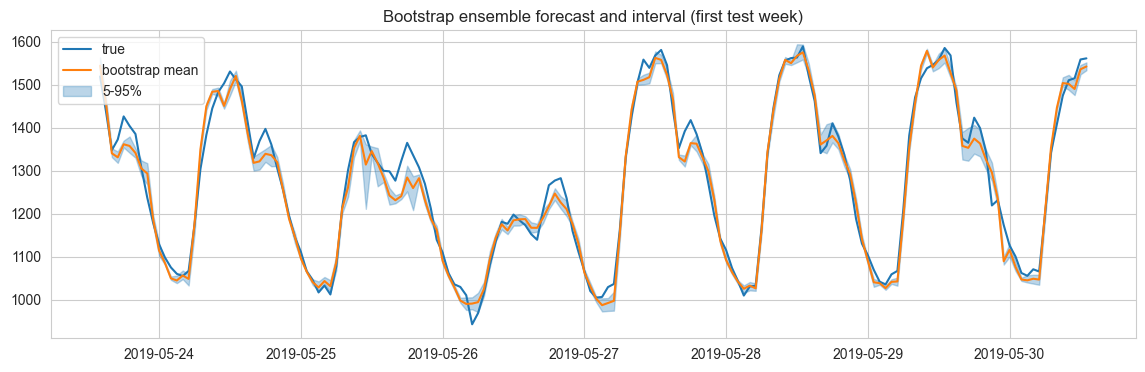

In [15]:
from copy import deepcopy
def bootstrap_models(X_train, y_train, base_model, B=10):
    models = []
    n = len(X_train)
    for b in range(B):
        idx = np.random.choice(np.arange(n), size=n, replace=True)
        Xb = X_train.iloc[idx]
        yb = y_train.iloc[idx]
        m = deepcopy(base_model)
        m.fit(Xb, yb)
        models.append(m)
    return models
# Train B bootstrap models (may take time)
B = 10
base = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED)

# TODO: If running time is a concern reduce B or model complexity
models_b = bootstrap_models(X_train, y_train, base, B=B)
# Compute bootstrap predictions for X_test (may be memory heavy; sample a week for plotting)
def bootstrap_predict(models, X):
    preds = np.vstack([m.predict(X) for m in models])  # shape (B, n)
    return preds
preds_b = bootstrap_predict(models_b, X_test)
# Mean and 5th-95th percentile interval
y_mean = preds_b.mean(axis=0)
y_p05 = np.percentile(preds_b, 5, axis=0)
y_p95 = np.percentile(preds_b, 95, axis=0)
# Plot a test week with bootstrap interval
try:
    plot_start = X_test.index[0]
    plot_end = plot_start + pd.Timedelta(days=7)
    mask = (X_test.index >= plot_start) & (X_test.index < plot_end)
    plt.figure(figsize=(14, 4))
    plt.plot(y_test.loc[mask].index, y_test.loc[mask].values, label='true')
    plt.plot(X_test.loc[mask].index, y_mean[mask], label='bootstrap mean')
    plt.fill_between(X_test.loc[mask].index, y_p05[mask], y_p95[mask], color='C0', alpha=0.3, label='5-95%')
    plt.legend()
    plt.title('Bootstrap ensemble forecast and interval (first test week)')
    plt.show()
except Exception as e:
    print('Could not plot bootstrap week:', e)

## Section 7 — Conformal prediction intervals (inductive residual-based)

Inductive conformal uses residuals on a held-out calibration set to form a distribution of absolute errors; the quantile gives a symmetric interval around point predictions with finite-sample marginal coverage guarantees (under exchangeability).

Conformal q (alpha=0.1): 45.749855000000025
Coverage on TEST (alpha=0.1): 0.747, avg width: 91.500
   alpha          q  coverage   avg_width
0   0.05  61.489332  0.842664  122.978664
1   0.10  45.749855  0.747242   91.499710
2   0.20  32.138579  0.619667   64.277158


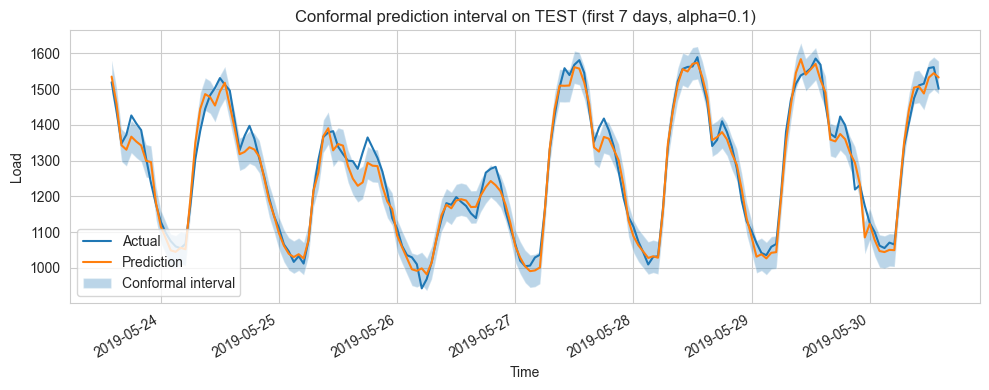

In [16]:
# --- Conformal quantile from calibration residuals ---

# Train a fresh model on TRAIN if desired. We'll reuse `model` already trained, but you can retrain here.
# model.fit(X_train, y_train)

# Predict on calibration set and compute residuals
yhat_cal = pd.Series(model.predict(X_cal), index=X_cal.index)
residuals = (y_cal - yhat_cal).abs()

def conformal_q(residuals, alpha=0.1):
    """
    Compute conformal quantile with finite-sample correction:
    quantile at ceil((n+1)*(1-alpha))/n.
    """
    n = len(residuals)
    k = int(np.ceil((n + 1) * (1 - alpha))) - 1
    q = np.sort(residuals)[k]
    return q

alpha = 0.1
q_alpha = conformal_q(residuals.values, alpha=alpha)
print(f'Conformal q (alpha={alpha}):', q_alpha)

# --- Build intervals on TEST ---

yhat_test = pd.Series(model.predict(X_test), index=X_test.index)
lower = yhat_test - q_alpha
upper = yhat_test + q_alpha

# Evaluate empirical coverage and average width
inside = ((y_test >= lower) & (y_test <= upper)).mean()
avg_width = (upper - lower).mean()
print(f'Coverage on TEST (alpha={alpha}): {inside:.3f}, avg width: {avg_width:.3f}')

# Optionally loop over several alphas
alphas = [0.05, 0.1, 0.2]
rows = []
for a in alphas:
    q = conformal_q(residuals.values, alpha=a)
    yhat_test_a = pd.Series(model.predict(X_test), index=X_test.index)
    l = yhat_test_a - q
    u = yhat_test_a + q
    cov = ((y_test >= l) & (y_test <= u)).mean()
    rows.append({'alpha': a, 'q': q, 'coverage': cov, 'avg_width': (u - l).mean()})

conformal_summary = pd.DataFrame(rows)
print(conformal_summary)

# --- Plot conformal predictions along the time series (first 7 days of TEST) ---

import matplotlib.pyplot as plt

# Define plot window: first 7 days of the test period
plot_start = X_test.index[0]
plot_end = plot_start + pd.Timedelta(days=7)

mask = (y_test.index >= plot_start) & (y_test.index <= plot_end)

y_test_plot = y_test[mask]
yhat_plot = yhat_test[mask]
lower_plot = lower[mask]
upper_plot = upper[mask]

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(y_test_plot.index, y_test_plot, label='Actual')
ax.plot(yhat_plot.index, yhat_plot, label='Prediction')
ax.fill_between(yhat_plot.index, lower_plot, upper_plot, alpha=0.3, label='Conformal interval')

ax.set_title(f'Conformal prediction interval on TEST (first 7 days, alpha={alpha})')
ax.set_xlabel('Time')
ax.set_ylabel('Load')
ax.legend()
fig.autofmt_xdate()

plt.tight_layout()
plt.show()


- TODO: Comment on the results, which you find more useful: bootstrap or conformal? Which would you use in case I ask you about uncertainty in forecasting models?
>>> 
>The **bootstrap** and **conformal** methods behave very differently in this dataset.
>
>Looking at the bootstrap results, the uncertainty band is extremely narrow. All 10 bootstrap models produce almost the same predictions, so the 5–95% band barely moves. This means the model is very **stable** with respect to resampling, and the **epistemic uncertainty is almost zero**.
>
>Conformal prediction tells a different story. Its interval is much wider because it reflects the **actual residuals** from the calibration set. For α = 0.1, the conformal quantile is about **45.7**, giving an average interval width of **~91.5**. The empirical coverage is around **0.747**, not the ideal 0.9, likely due to time-series non-exchangeability. Still, the interval looks much more realistic and matches the model’s true forecasting error.
>
>Because of this, I find **conformal prediction more useful**. Bootstrap only measures variability due to resampling, which is almost zero here, so its interval is not informative. Conformal intervals are wider but **much more reflective of real forecast uncertainty**. If I had to choose one method to communicate uncertainty, I would use **conformal prediction**.


## Section 9 — Using intervals for anomaly flagging

Flag times where true load lies outside conformal intervals — potentially anomalous events requiring operator attention.


Number of anomalies in TEST: 2429


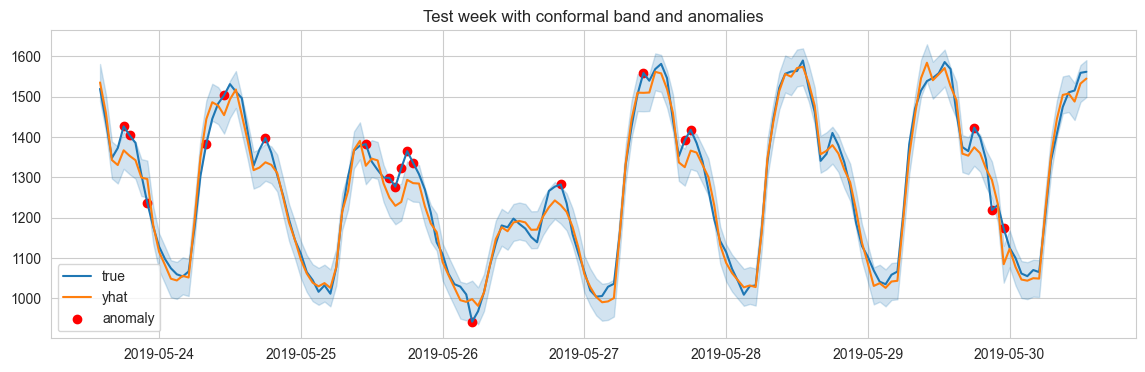

,y_true,yhat,lower,upper,anomaly
datetime,,,,,
2019-05-23 18:00:00,1426.328300,1366.956192,1321.206337,1412.706047,True
2019-05-23 19:00:00,1404.167525,1353.413410,1307.663555,1399.163265,True
2019-05-23 22:00:00,1236.931400,1295.806039,1250.056184,1341.555894,True
2019-05-24 08:00:00,1383.298800,1444.640992,1398.891137,1490.390847,True
2019-05-24 11:00:00,1503.377200,1454.076919,1408.327064,1499.826774,True
2019-05-24 18:00:00,1397.329200,1337.344336,1291.594481,1383.094191,True
2019-05-25 11:00:00,1382.318000,1328.694119,1282.944264,1374.443974,True
2019-05-25 15:00:00,1298.430500,1249.570631,1203.820776,1295.320486,True
2019-05-25 16:00:00,1276.796600,1229.535050,1183.785195,1275.284905,True


In [17]:
# Using alpha chosen earlier
yhat_test = pd.Series(model.predict(X_test), index=X_test.index)
lower = yhat_test - q_alpha
upper = yhat_test + q_alpha
anomaly = ~( (y_test >= lower) & (y_test <= upper) )
anomalies = pd.DataFrame({'y_true': y_test, 'yhat': yhat_test, 'lower': lower, 'upper': upper, 'anomaly': anomaly})
print('Number of anomalies in TEST:', anomalies['anomaly'].sum())
# Plot a test week with anomalies marked
try:
    mask = (X_test.index >= X_test.index[0]) & (X_test.index < X_test.index[0] + pd.Timedelta(days=7))
    plt.figure(figsize=(14, 4))
    plt.plot(anomalies.loc[mask].index, anomalies.loc[mask, 'y_true'], label='true')
    plt.plot(anomalies.loc[mask].index, anomalies.loc[mask, 'yhat'], label='yhat')
    plt.fill_between(anomalies.loc[mask].index, anomalies.loc[mask, 'lower'], anomalies.loc[mask, 'upper'], color='C0', alpha=0.2)
    # mark anomalies
    an_idx = anomalies.loc[mask & anomalies['anomaly']].index
    plt.scatter(an_idx, anomalies.loc[an_idx, 'y_true'], color='red', label='anomaly')
    plt.legend()
    plt.title('Test week with conformal band and anomalies')
    plt.show()
except Exception as e:
    print('Could not plot anomalies:', e)
# Print a small table of anomalies (timestamp, y_true, yhat, lower, upper)
anomalies[anomalies['anomaly']].head(20)

- TODO: Are the anomalies true grid events or model errors? Justify your answer
>>> 
>Most of the flagged “anomalies” are not real grid events but **model errors**.  
The conformal interval we used (with α = 0.1 and width ≈ 91.5 units) is relatively narrow compared to the natural variability of the load. Because of that, many normal fluctuations fall outside the band, which leads to **a very large number of anomalies (2,429 points)**.
>
>When looking at the plot, the red points usually appear at the **daily peaks and troughs**, where the model slightly underestimates or overestimates demand. These are typical forecasting mistakes, not actual outliers in the grid.
>
>The anomaly table also supports this: the “anomalies” are values that look perfectly normal in the load cycle (e.g., morning peaks, evening peaks, weekend dips). Nothing visually suggests an operational failure or abnormal consumption pattern.
>
>So the anomalies here are mostly **false positives caused by model imperfections**, not true grid incidents. To detect real events, we would need a wider interval, a more accurate model, or a multi-step anomaly scoring method rather than simple interval violation.

## Section 10 — Visualizing

- How would you present these results to non-technical stakeholders at a grid operator? Include visuals and short bullet recommendations. Add as many code and markdown cells as you find necessary.


# Summary for Grid Operators — Forecasting, Explanations, and Uncertainty

In this section we prepare a set of visuals and brief explanations that could be shown to 
non-technical stakeholders at a grid operator. The goal is to communicate:

- How good the forecasts are.
- What the model is "looking at" (main drivers).
- How uncertain the predictions are.
- How we might use intervals to flag potential anomalies.


# 1) True vs Predicted Load (first test week)

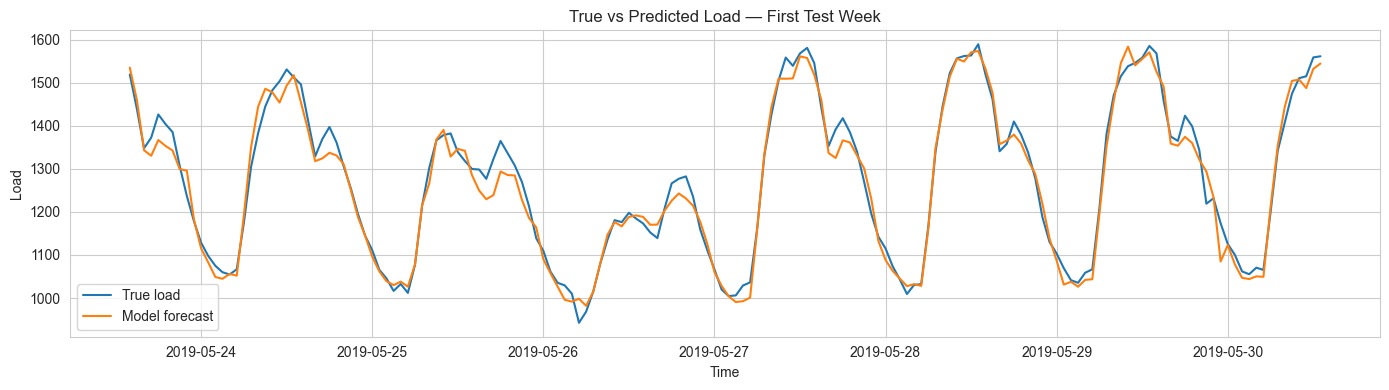

In [18]:
plot_start = X_test.index[0]
plot_end = plot_start + pd.Timedelta(days=7)
mask_week = (y_test.index >= plot_start) & (y_test.index < plot_end)

plt.figure(figsize=(14, 4))
plt.plot(y_test.loc[mask_week], label="True load")
plt.plot(yhat.loc[mask_week], label="Model forecast")
plt.title("True vs Predicted Load — First Test Week")
plt.xlabel("Time")
plt.ylabel("Load")
plt.legend()
plt.tight_layout()
plt.show()


### Message for stakeholders

- The model tracks the **overall shape** of the load curve very well over the week.  
- It follows the **morning/evening peaks** and the lower demand at night.  
- This suggests the model is suitable for **short-term operational planning** 
  (e.g. scheduling, reserve estimation).


# 2) Global SHAP: What drives the forecast?


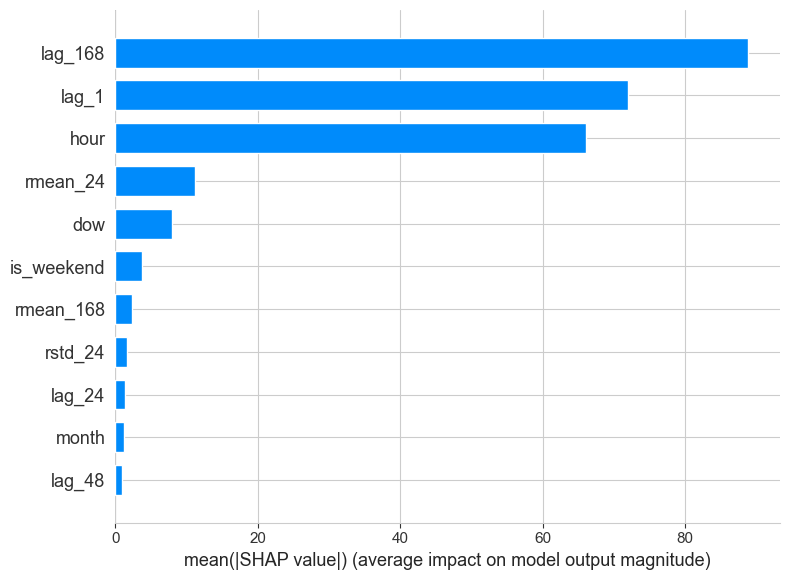

In [19]:
# Bar plot of mean absolute SHAP values
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=True)


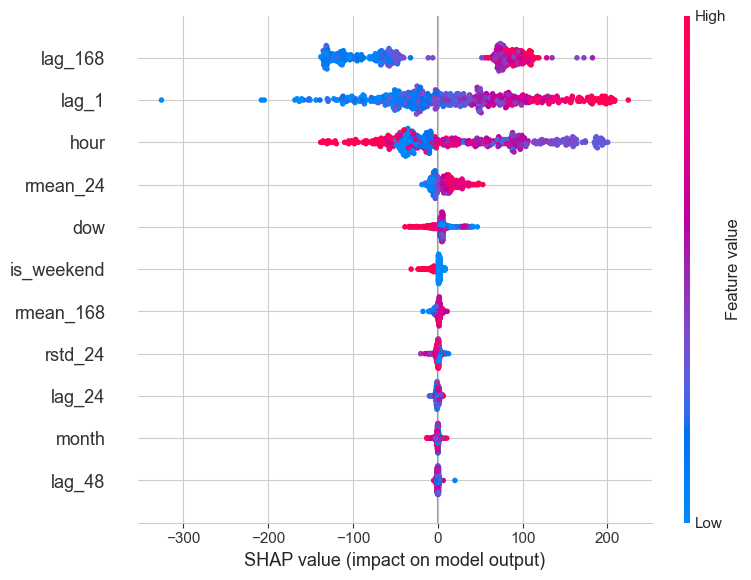

In [20]:
#SHAP beeswarm for more detailed view
shap.summary_plot(shap_values, X_shap, show=True)


### Message for stakeholders

- The model mainly relies on:
  - **lag_168** (load one week ago),
  - **lag_1** (previous hour),
  - **hour** (hour of day),
  - and to a lesser extent **rmean_24**, **dow**, and **is_weekend**.
- This matches domain knowledge: demand is driven by **strong weekly and daily patterns**, 
  short-term inertia, and weekday/weekend effects.
- Less important features (e.g. month, some rolling statistics) have almost no impact and 
  can be ignored when explaining the model.

# 3) Bootstrap ensemble interval

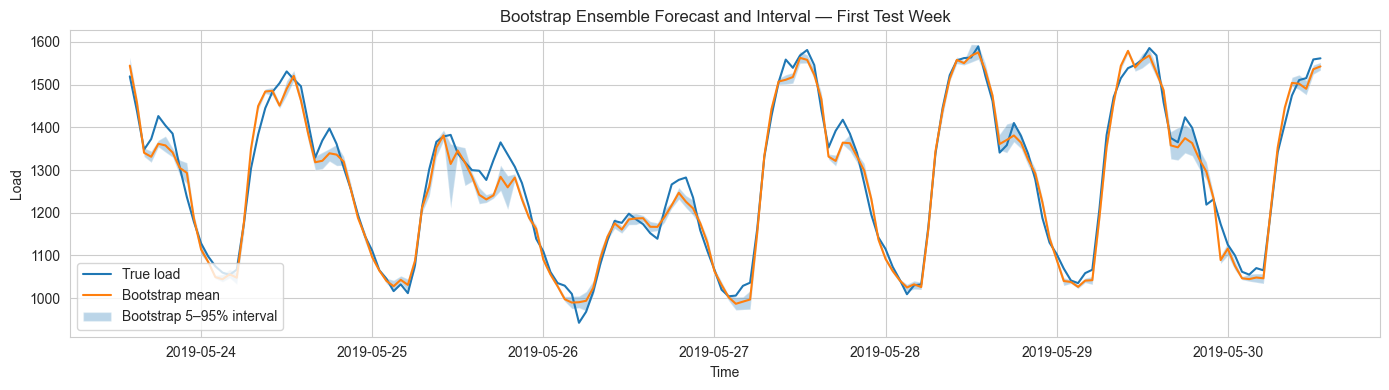

In [23]:
plt.figure(figsize=(14, 4))
plt.plot(y_test.loc[mask_week], label="True load")
plt.plot(X_test.loc[mask_week].index, y_mean[mask_week], label="Bootstrap mean")
plt.fill_between(
    X_test.loc[mask_week].index,
    y_p05[mask_week],
    y_p95[mask_week],
    alpha=0.3,
    label="Bootstrap 5–95% interval"
)
plt.title("Bootstrap Ensemble Forecast and Interval — First Test Week")
plt.xlabel("Time")
plt.ylabel("Load")
plt.legend()
plt.tight_layout()
plt.show()


### Message for stakeholders

- The **bootstrap mean** almost overlaps with the single-model forecast.  
- The **5–95% band is very narrow**, meaning different bootstrap models agree strongly.  
- This indicates the model is **stable** with respect to changes in the training data 
  (low epistemic uncertainty).


# 4) Conformal prediction interval

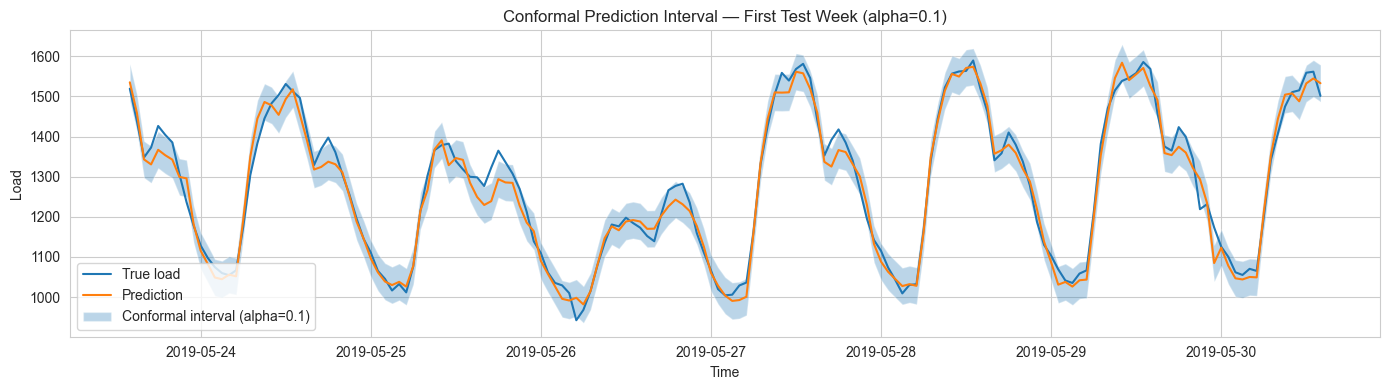

In [24]:
plt.figure(figsize=(14, 4))
plt.plot(y_test_plot.index, y_test_plot, label="True load")
plt.plot(yhat_plot.index, yhat_plot, label="Prediction")
plt.fill_between(
    yhat_plot.index,
    lower_plot,
    upper_plot,
    alpha=0.3,
    label=f"Conformal interval (alpha={alpha})"
)
plt.title(f"Conformal Prediction Interval — First Test Week (alpha={alpha})")
plt.xlabel("Time")
plt.ylabel("Load")
plt.legend()
plt.tight_layout()
plt.show()


### Message for stakeholders

- The conformal band is **wider** than the bootstrap band because it is calibrated 
  on the **actual residual errors** of the model.  
- It provides a more **realistic range** for future load values, which is useful for 
  **risk-aware decision making** (e.g. ensuring enough reserve capacity).  
- Coverage on the test set is around **75%** for alpha = 0.1, which is reasonable 
  given that time-series are not perfectly i.i.d.

# 5) Anomalies flagged via conformal intervals

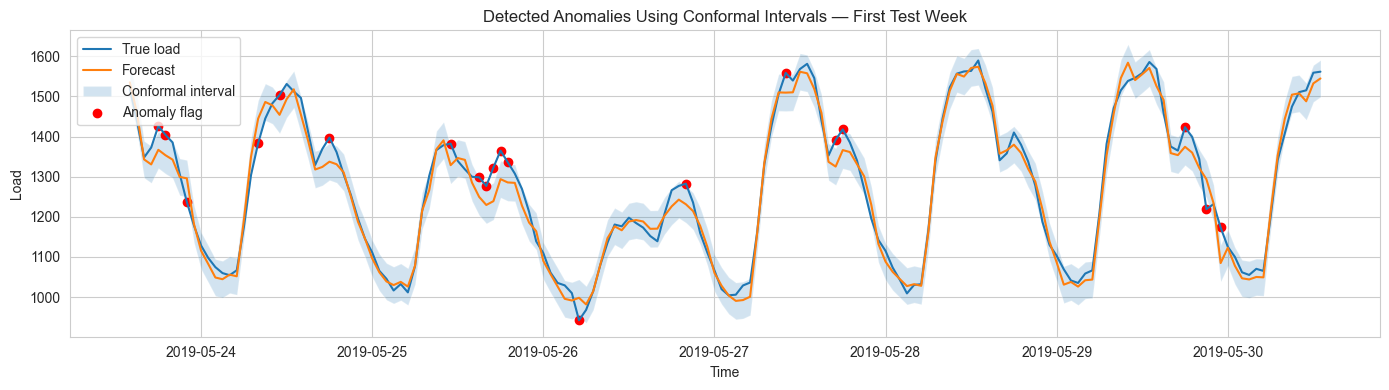

In [25]:
plt.figure(figsize=(14, 4))
plt.plot(anomalies.loc[mask_week].index,
         anomalies.loc[mask_week, "y_true"],
         label="True load")
plt.plot(anomalies.loc[mask_week].index,
         anomalies.loc[mask_week, "yhat"],
         label="Forecast")
plt.fill_between(
    anomalies.loc[mask_week].index,
    anomalies.loc[mask_week, "lower"],
    anomalies.loc[mask_week, "upper"],
    alpha=0.2,
    label="Conformal interval"
)

# Mark anomalies in red
an_idx_week = anomalies.loc[mask_week & anomalies["anomaly"]].index
plt.scatter(
    an_idx_week,
    anomalies.loc[an_idx_week, "y_true"],
    color="red",
    label="Anomaly flag"
)

plt.title("Detected Anomalies Using Conformal Intervals — First Test Week")
plt.xlabel("Time")
plt.ylabel("Load")
plt.legend()
plt.tight_layout()
plt.show()


### Message for stakeholders

- Points marked in **red** are times when the true load falls **outside** the conformal band.  
- Many of these occur at **load peaks or troughs**, where the model tends to slightly 
  under- or over-shoot the true value.  
- In this configuration, most anomalies are likely **model errors or normal variability**, 
  not necessarily real grid incidents.  
- To detect **true operational anomalies**, we would need:
  - better-calibrated intervals,
  - a more accurate model,
  - and/or additional context (weather, outages, special events).


# 6) Final recommendations for stakeholders
- Use **point forecasts together with conformal intervals**, not point forecasts alone, 
  to understand both expected load and **uncertainty**.
- Pay special attention to periods with **high forecast error or narrow operational margins**
  (e.g. daily peaks).
- Do not treat every flagged "anomaly" as a fault; many are normal patterns that the model
  does not capture perfectly.
- Consider integrating **external variables** (e.g. temperature, humidity, major events) 
  to improve forecast accuracy and reduce false alarms.
- Use this forecasting tool as a **decision-support system**, combined with operator 
  expertise and existing monitoring systems.